In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Unemployment in India.csv")

# Display first 5 rows
print(df.head())

# Shape of dataset
print("\nShape of Dataset:")
print(df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.info())


           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  

Shape of Dataset:
(768, 7)

Columns:
Index(['Region', ' Date', ' Frequency', ' E

In [ ]:
print(df.isnull().sum())


In [7]:
df = df.dropna()


In [8]:
print(df.shape)


(740, 7)


In [10]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [12]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print(df['Date'].head())
print(df['Date'].dtype)

0   2019-05-31
1   2019-06-30
2   2019-07-31
3   2019-08-31
4   2019-09-30
Name: Date, dtype: datetime64[ns]
datetime64[ns]


In [13]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()

print(df[['Date', 'Year', 'Month']].head())

        Date  Year      Month
0 2019-05-31  2019        May
1 2019-06-30  2019       June
2 2019-07-31  2019       July
3 2019-08-31  2019     August
4 2019-09-30  2019  September


In [14]:
print(df.describe())

                                Date  Estimated Unemployment Rate (%)  \
count                            740                       740.000000   
mean   2019-12-12 18:36:58.378378496                        11.787946   
min              2019-05-31 00:00:00                         0.000000   
25%              2019-08-31 00:00:00                         4.657500   
50%              2019-11-30 00:00:00                         8.350000   
75%              2020-03-31 00:00:00                        15.887500   
max              2020-06-30 00:00:00                        76.740000   
std                              NaN                        10.721298   

       Estimated Employed  Estimated Labour Participation Rate (%)  \
count        7.400000e+02                               740.000000   
mean         7.204460e+06                                42.630122   
min          4.942000e+04                                13.330000   
25%          1.190404e+06                                38.06

In [15]:
print("Number of regions:", df['Region'].nunique())

print("\nRegions:")
print(df['Region'].unique())

Number of regions: 28

Regions:
['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' 'Chandigarh']


In [16]:
print(df['Area'].value_counts())

Area
Urban    381
Rural    359
Name: count, dtype: int64


In [17]:
print(df.groupby('Area')['Estimated Unemployment Rate (%)'].mean())

Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64


In [18]:
top_states = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

print(top_states.head(10))

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64


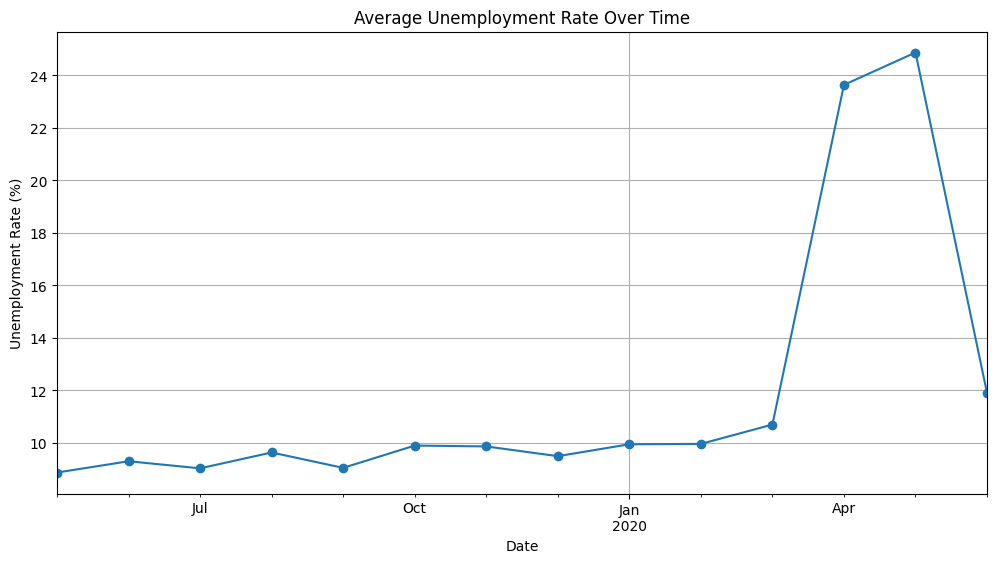

In [19]:
monthly_trend = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(12,6))
monthly_trend.plot(marker='o')

plt.title('Average Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.grid(True)

plt.show()

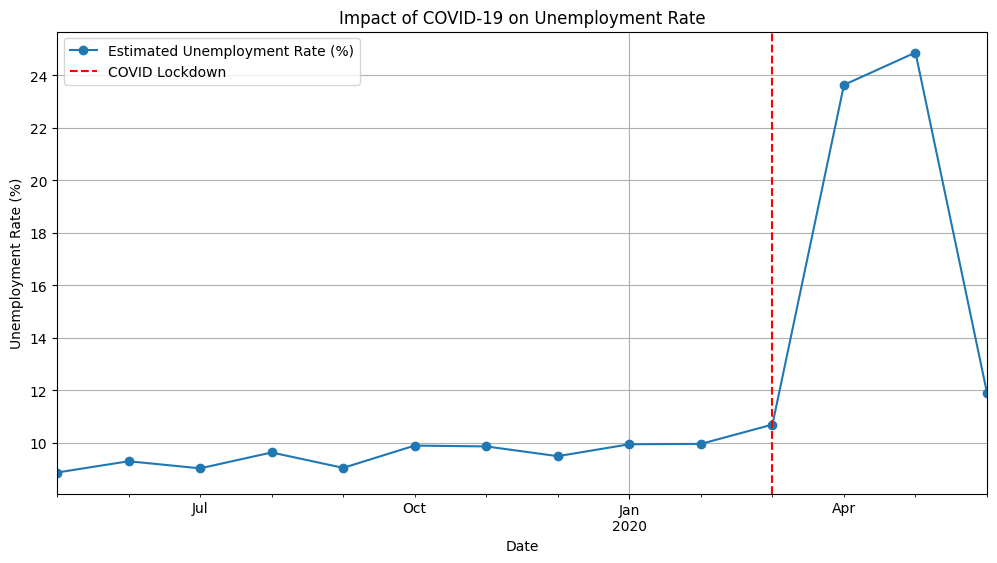

In [20]:
plt.figure(figsize=(12,6))

monthly_trend.plot(marker='o')

plt.axvline(pd.Timestamp('2020-03-24'),
            color='red',
            linestyle='--',
            label='COVID Lockdown')

plt.title('Impact of COVID-19 on Unemployment Rate')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')

plt.legend()
plt.grid(True)

plt.show()

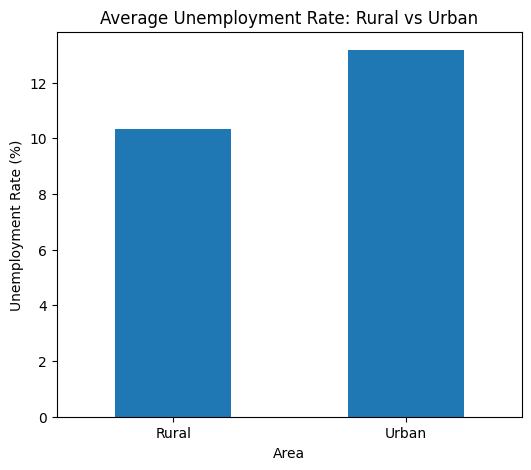

In [21]:
area_avg = df.groupby('Area')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(6,5))

area_avg.plot(kind='bar')

plt.title('Average Unemployment Rate: Rural vs Urban')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=0)

plt.show()

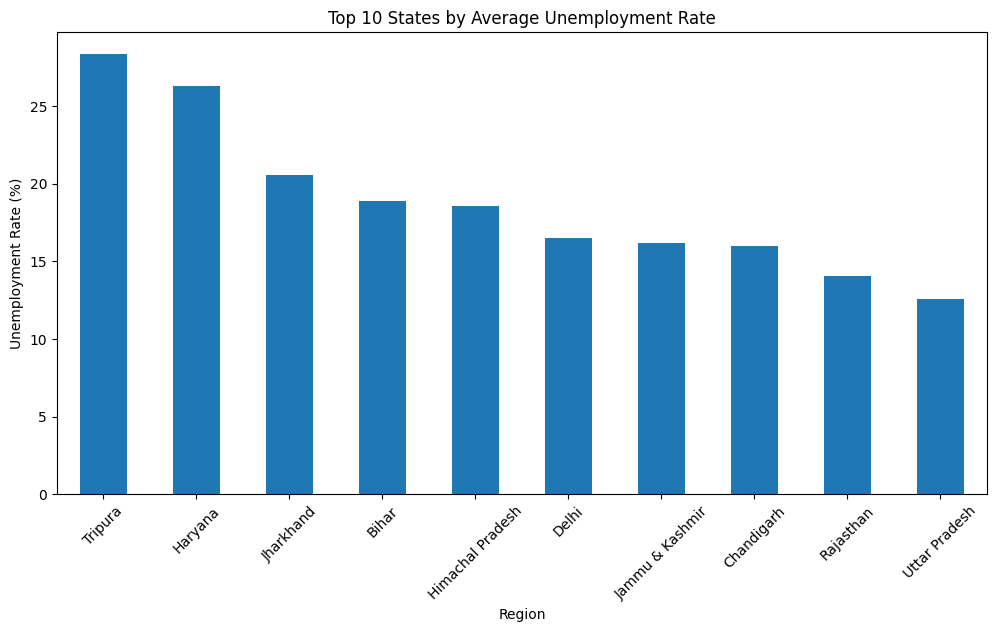

In [22]:
plt.figure(figsize=(12,6))

top_states.head(10).plot(kind='bar')

plt.title('Top 10 States by Average Unemployment Rate')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)

plt.show()

In [23]:
month_order = ['January', 'February', 'March', 'April',
               'May', 'June', 'July', 'August',
               'September', 'October', 'November', 'December']

monthly_pattern = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

monthly_pattern = monthly_pattern.reindex(month_order)

print(monthly_pattern)

Month
January       9.950755
February      9.964717
March        10.700577
April        23.641569
May          16.646190
June         10.553462
July          9.033889
August        9.637925
September     9.051731
October       9.900909
November      9.868364
December      9.497358
Name: Estimated Unemployment Rate (%), dtype: float64


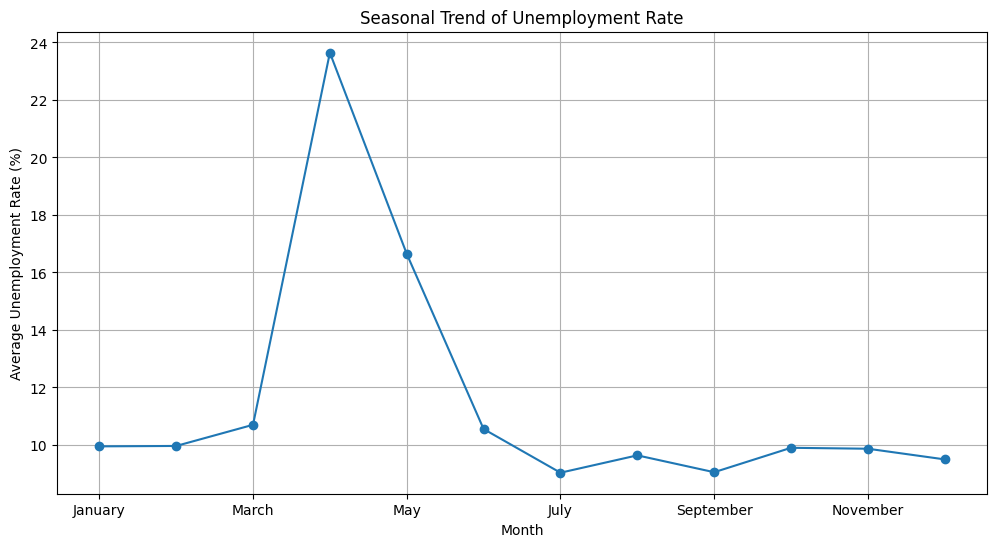

In [24]:
plt.figure(figsize=(12,6))

monthly_pattern.plot(marker='o')

plt.title('Seasonal Trend of Unemployment Rate')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')
plt.grid(True)

plt.show()

In [26]:
df['Period'] = df['Date'].apply(
    lambda x: 'Pre-COVID' if x < pd.Timestamp('2020-03-24') else 'COVID Period'
)

comparison = df.groupby('Period')['Estimated Unemployment Rate (%)'].mean()

print(comparison)

Period
COVID Period    17.774363
Pre-COVID        9.509534
Name: Estimated Unemployment Rate (%), dtype: float64


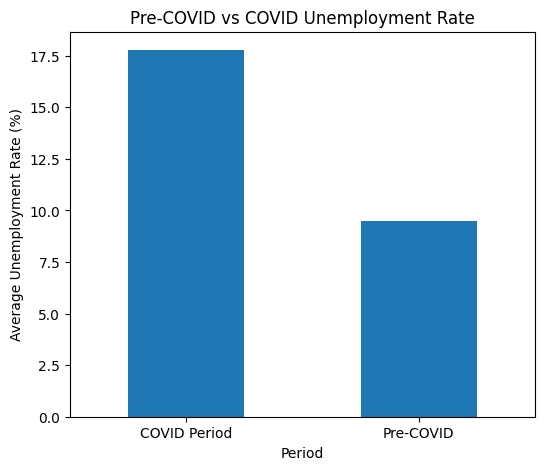

In [27]:
plt.figure(figsize=(6,5))

comparison.plot(kind='bar')

plt.title('Pre-COVID vs COVID Unemployment Rate')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=0)

plt.show()

In [28]:
''' Insights and Conclusions

1. The average unemployment rate in India increased during the COVID-19 period, rising from 9.51% before the pandemic to 17.77% during the pandemic.

2. The highest unemployment rates were seen in April and May 2020, which was the period of the nationwide lockdown.

3. Urban areas had a higher average unemployment rate (13.17%) than rural areas (10.32%). This shows that cities were more affected by the pandemic.

4. Tripura and Haryana had the highest average unemployment rates among the states studied. These states may need more attention and support to improve employment opportunities.

5. Except for the COVID-19 period, unemployment rates stayed mostly stable throughout the year. This suggests that the sharp increase in unemployment was mainly caused by the pandemic.

Policy Recommendations

1. Improve employment support programs to help people during economic crises.

2. Provide financial support to small businesses so they can keep their employees.

3. Offer more skill development and training programs to help people find jobs more easily.

4. Create employment programs focused on urban areas, where unemployment was higher.

5. Prepare emergency plans to reduce job losses during future crises or disasters.'''